<a href="https://colab.research.google.com/github/nouur-mohaamed/CreditCardDefault_ML_Project/blob/main/credit_card_default_final_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [364]:
!pip install ucimlrepo

In [435]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.metrics import (f1_score,precision_score,recall_score,classification_report,accuracy_score,confusion_matrix,ConfusionMatrixDisplay)

#1. Upload and extract the data

In [366]:
# fetch dataset
credit_card_default_fetched_object = fetch_ucirepo(id=350)

In [367]:
credit_card_default_fetched_object.data

{'ids':           ID
 0          1
 1          2
 2          3
 3          4
 4          5
 ...      ...
 29995  29996
 29996  29997
 29997  29998
 29998  29999
 29999  30000
 
 [30000 rows x 1 columns],
 'features':            X1  X2  X3  X4  X5  X6  X7  X8  X9  X10  ...     X14    X15    X16  \
 0       20000   2   2   1  24   2   2  -1  -1   -2  ...     689      0      0   
 1      120000   2   2   2  26  -1   2   0   0    0  ...    2682   3272   3455   
 2       90000   2   2   2  34   0   0   0   0    0  ...   13559  14331  14948   
 3       50000   2   2   1  37   0   0   0   0    0  ...   49291  28314  28959   
 4       50000   1   2   1  57  -1   0  -1   0    0  ...   35835  20940  19146   
 ...       ...  ..  ..  ..  ..  ..  ..  ..  ..  ...  ...     ...    ...    ...   
 29995  220000   1   3   1  39   0   0   0   0    0  ...  208365  88004  31237   
 29996  150000   1   3   2  43  -1  -1  -1  -1    0  ...    3502   8979   5190   
 29997   30000   1   2   2  37   4   3   2  -1

In [368]:
features=credit_card_default_fetched_object.data.features
features

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,3502,8979,5190,0,1837,3526,8998,129,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,...,2758,20878,20582,19357,0,0,22000,4200,2000,3100
29998,80000,1,3,1,41,1,-1,0,0,0,...,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804


In [369]:
targets=credit_card_default_fetched_object.data.targets
targets

,Y
0,1
1,1
2,0
3,0
4,0
...,...
29995,0
29996,0
29997,1
29998,1


In [370]:
full_credit_card_data_table=pd.concat([features,targets],axis=1)
full_credit_card_data_table

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,80000,1,3,1,41,1,-1,0,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


#2. Understand the data

*   number of samples: 30,000
*   number of features: 23
*   Target : default? [ 1--> yes , 0--> no ]
*   Numerical features: Amount of the given credit,Age,Amount of bill statement,Amount of previous payment
*   Categorical features: Gender,Education,Marital status,History of past payment

### features meaning:
* Amount of the given credit [X1]: the credit limit given to that person (can't exceed)
* Amount of bill statement [X12-X17]: how much does he owe the bank at this month report
* Amount of previous payment[X18-X23]: how much of what he was owed did he pay at this month report
* History of past payment[X6 - X11]: what is his payment status at this month report ( was he delayed or not and by how many months was he delayed)

#3. EDA (part 1)


---



In [371]:
full_credit_card_data_table.shape

(30000, 24)

we have 30,000 sample which is relativly small

In [372]:
full_credit_card_data_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      30000 non-null  int64
 1   X2      30000 non-null  int64
 2   X3      30000 non-null  int64
 3   X4      30000 non-null  int64
 4   X5      30000 non-null  int64
 5   X6      30000 non-null  int64
 6   X7      30000 non-null  int64
 7   X8      30000 non-null  int64
 8   X9      30000 non-null  int64
 9   X10     30000 non-null  int64
 10  X11     30000 non-null  int64
 11  X12     30000 non-null  int64
 12  X13     30000 non-null  int64
 13  X14     30000 non-null  int64
 14  X15     30000 non-null  int64
 15  X16     30000 non-null  int64
 16  X17     30000 non-null  int64
 17  X18     30000 non-null  int64
 18  X19     30000 non-null  int64
 19  X20     30000 non-null  int64
 20  X21     30000 non-null  int64
 21  X22     30000 non-null  int64
 22  X23     30000 non-null  int64
 23  Y       300

*   all features are numerical values (categorial or non)
*   the data set contain no null values



In [373]:
full_credit_card_data_table.isnull().sum().sum()

np.int64(0)

no null values (confirmed)


---
we would deal with null
either by dropping the row / filling it with value

*  code Examples:-

dropping the row
```
# drop all rows with at leat one null value
df_cleaned = df.dropna()
#drop all columns with at least one null value
df_cleaned = df.dropna(axis=1)
```
filling it with value
(0,median,mean)
```
df_filled = df.fillna(0)
```
```
df['Column_Name'] = df['Column_Name'].fillna(df['Column_Name'].median())

```




In [374]:
full_credit_card_data_table.duplicated().sum()

np.int64(35)

we have 35 duplicate rows

# Preprocessing (part 1) " remove duplicates "

In [375]:
full_credit_card_data_table.drop_duplicates(inplace=True)
full_credit_card_data_table.reset_index(drop=True, inplace=True)

In [376]:
full_credit_card_data_table.isnull().sum().sum()

np.int64(0)

#4. Train-Test-Split

In [377]:
train,test=train_test_split(full_credit_card_data_table,test_size=0.2,random_state=42,stratify=full_credit_card_data_table['Y'])

In [378]:
train.reset_index(drop=True, inplace=True)
test.reset_index(drop=True, inplace=True)

In [379]:
y_train=train['Y']
y_test=test['Y']
x_train=train.drop(columns=['Y'])
x_test=test.drop(columns=['Y'])

#5. EDA (part 2)

In [380]:
train.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
count,23972.000000,23972.000000,23972.000000,23972.000000,23972.000000,23972.000000,23972.000000,23972.000000,23972.000000,23972.000000,...,23972.000000,23972.000000,23972.000000,23972.000000,2.397200e+04,23972.000000,23972.000000,23972.000000,23972.000000,23972.000000
mean,167272.638078,1.601952,1.851285,1.553104,35.462248,-0.012223,-0.128191,-0.163024,-0.219256,-0.265685,...,43378.609795,40381.773444,38899.466044,5652.104330,5.933725e+03,5224.315785,4807.290005,4791.897255,5264.869306,0.221258
std,129869.870528,0.489506,0.791491,0.522706,9.196570,1.121827,1.194928,1.189572,1.163881,1.127085,...,64355.851717,60717.985167,59577.264417,16680.809675,2.415227e+04,17711.547254,14981.334469,15036.819963,18197.834701,0.415103
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-81334.000000,-61372.000000,-339603.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2400.000000,1781.750000,1242.750000,1000.000000,8.520000e+02,396.000000,295.250000,264.000000,133.000000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19194.000000,18219.500000,17135.000000,2100.000000,2.010000e+03,1815.500000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54715.250000,50524.000000,49264.250000,5009.000000,5.000000e+03,4503.000000,4038.500000,4009.250000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,75.000000,8.000000,7.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.000000,621000.000000,417990.000000,528666.000000,1.000000


### scaling numerical features is required
---
based on max value and other (like mean,median...etc) we observe that the numerical features have different scales.

<Axes: xlabel='Y'>

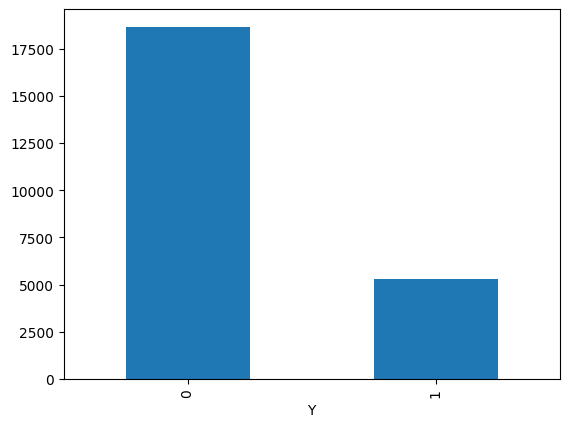

In [381]:
y_train.value_counts().plot(kind='bar')

In [382]:
round((y_train.value_counts()/y_train.shape[0])*100)

,count
Y,
0,78.0
1,22.0


### data is imbalanced

---



*   78% of samples are non default
*   22% of samples are default


---


that will cause the model to be biased to preform well in predicting non default class while poorly in predicting the default class (recall of default class is expexted to be bad!)



In [383]:
x_train['X2'].value_counts() # male-> 1 / female-> 2


,count
X2,
2,14430
1,9542


no unusual values :)

In [384]:
x_train['X3'].value_counts() #Education (1 = graduate school; 2 = university; 3 = high school; 4 = others).

,count
X3,
2,11250
1,8473
3,3871
5,235
4,90
6,43
0,10


unusual values: 5,6,0 --> should be 4

In [385]:
x_train['X4'].value_counts() #Marital status (1 = married; 2 = single; 3 = others).

,count
X4,
2,12773
1,10887
3,266
0,46


unusual values: 0 --> should be 3

### checking the distribution of features

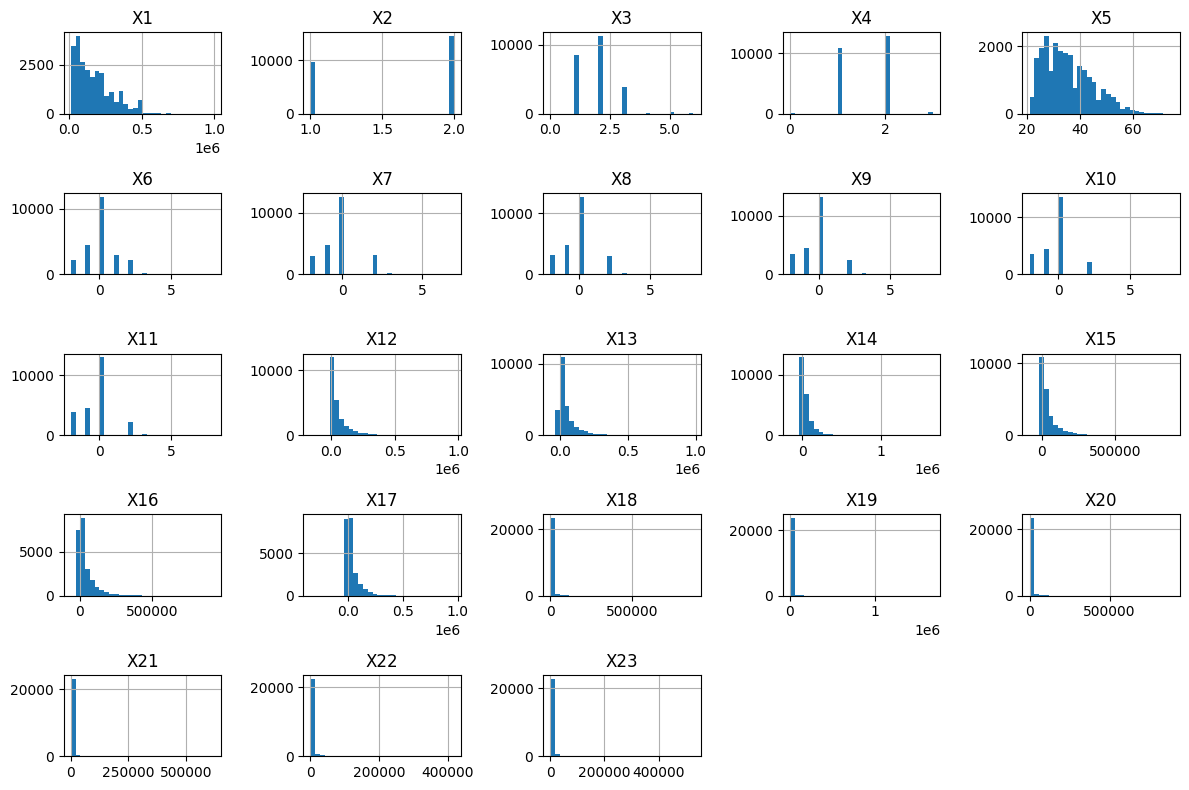

In [386]:
x_train.hist(figsize=(12, 8), bins=30)

plt.tight_layout()
plt.show()

In [387]:
x_train['X5'].mean()

np.float64(35.46224762222593)

In [388]:
x_train['X5'].mode()

,X5
0,29


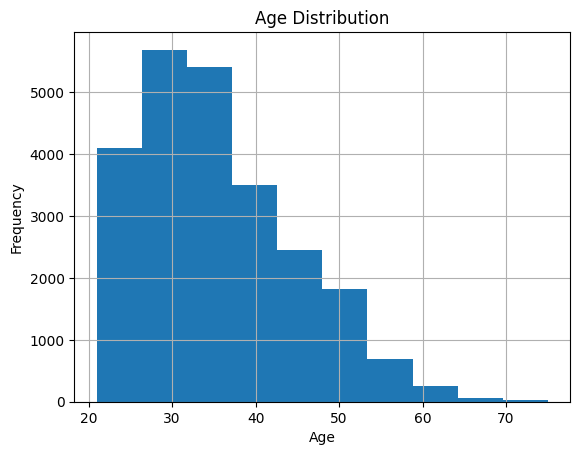

In [389]:
x_train['X5'].hist(bins=10)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()


In [390]:
x_train['X12'].mean()

np.float64(51270.568621725346)

In [391]:
x_train['X12'].mode()

,X12
0,0


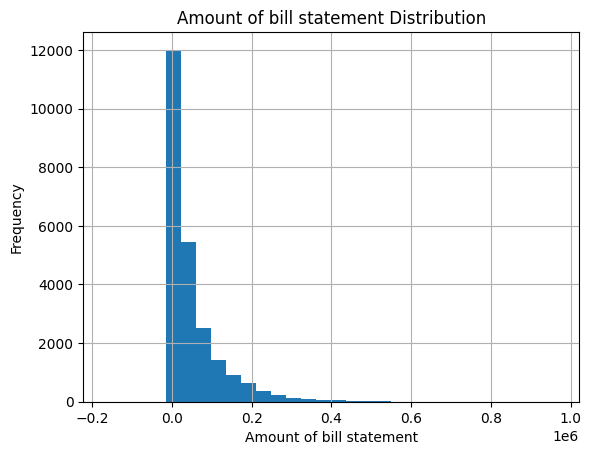

In [392]:
x_train['X12'].hist(bins=30)
plt.xlabel('Amount of bill statement')
plt.ylabel('Frequency')
plt.title('Amount of bill statement Distribution')
plt.show()

In [393]:
x_train['X17'].mean()

np.float64(38899.46604371767)

In [394]:
x_train['X17'].mode()

,X17
0,0


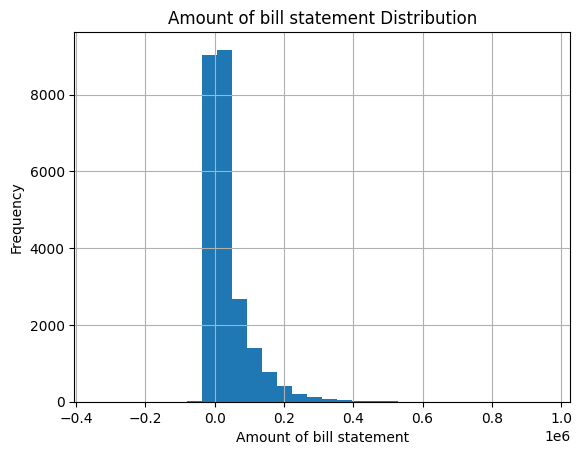

In [395]:
x_train['X17'].hist(bins=30)
plt.xlabel('Amount of bill statement')
plt.ylabel('Frequency')
plt.title('Amount of bill statement Distribution')
plt.show()

In [396]:
x_train['X18'].mean()

np.float64(5652.104330051727)

In [397]:
x_train['X18'].mode()

,X18
0,0


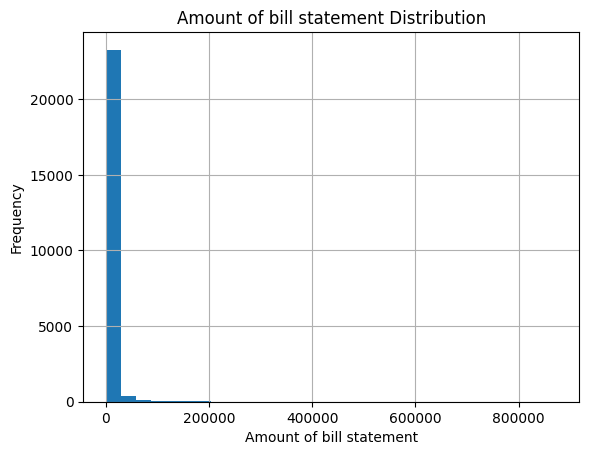

In [398]:
x_train['X18'].hist(bins=30)
plt.xlabel('Amount of bill statement')
plt.ylabel('Frequency')
plt.title('Amount of bill statement Distribution')
plt.show()

In [399]:
x_train['X23'].mean()

np.float64(5264.869305856833)

In [400]:
x_train['X23'].mode()

,X23
0,0


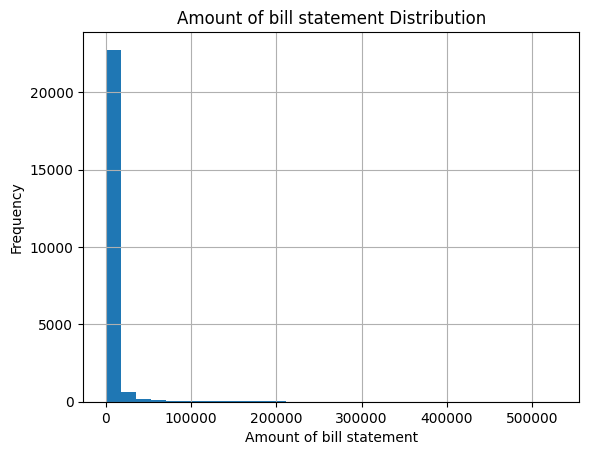

In [401]:
x_train['X23'].hist(bins=30)
plt.xlabel('Amount of bill statement')
plt.ylabel('Frequency')
plt.title('Amount of bill statement Distribution')
plt.show()

conclusion:
* Age--> kind of symmetric (normal)
* Amount of bill statement-->right skewed (majority 0)
* Amount of previous payment--> extrmely right skewed

### Box plots — detecting outliers (numerical unusual values)

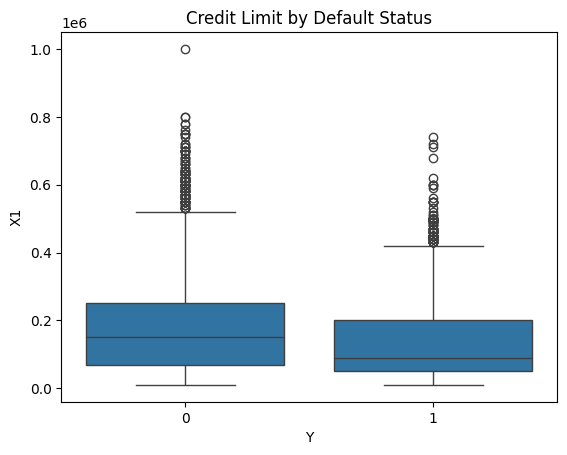

In [402]:
sns.boxplot(
    x="Y",
    y="X1",
    data=train
)

plt.title("Credit Limit by Default Status")
plt.show()

conclusion:
* Customers who do not default generally hold higher credit lines, likely because banks pre-screen higher-income or lower-risk clients with higher limits.
* Even though high credit limits are safer on average, there are still notable outliers in group 1 defaulting at limits up to $750,000$, indicating credit limit alone isn't a perfect predictor.

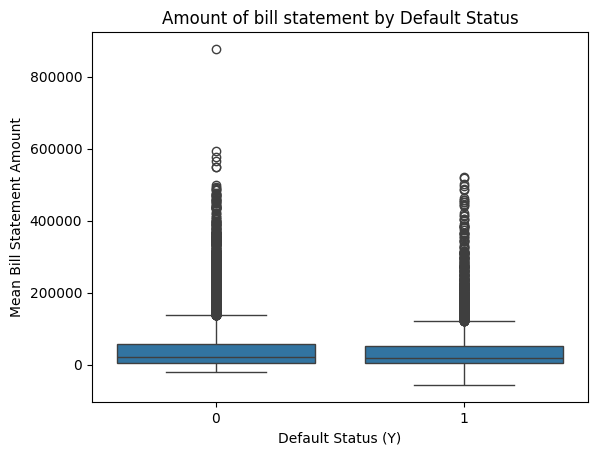

In [403]:
sns.boxplot(
    x=train['Y'],
    y=train[['X12','X13','X14','X15','X16','X17']].mean(axis=1)
)
plt.xlabel("Default Status (Y)")
plt.ylabel("Mean Bill Statement Amount")
plt.title("Amount of bill statement by Default Status")
plt.show()

conclusion:
* amount of bill statment alone provide low predictive power since no significant difference in distribution between defaulters and non defaulters.

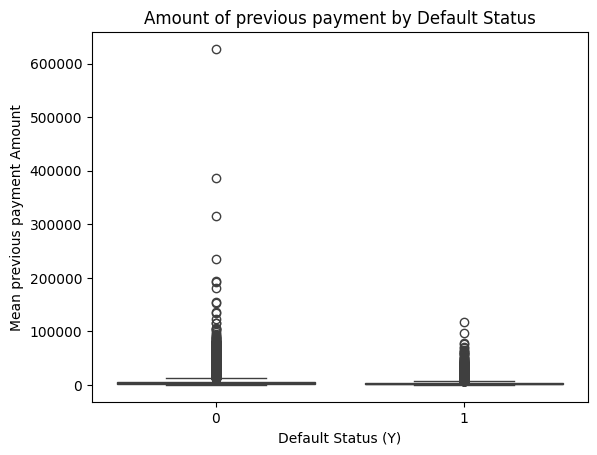

In [404]:
sns.boxplot(
    x=train['Y'],
    y=train[['X18','X19','X20','X21','X22','X23']].mean(axis=1)
)
plt.xlabel("Default Status (Y)")
plt.ylabel("Mean previous payment Amount")
plt.title("Amount of previous payment by Default Status")
plt.show()

### Categorical variable frequency

<function matplotlib.pyplot.show(close=None, block=None)>

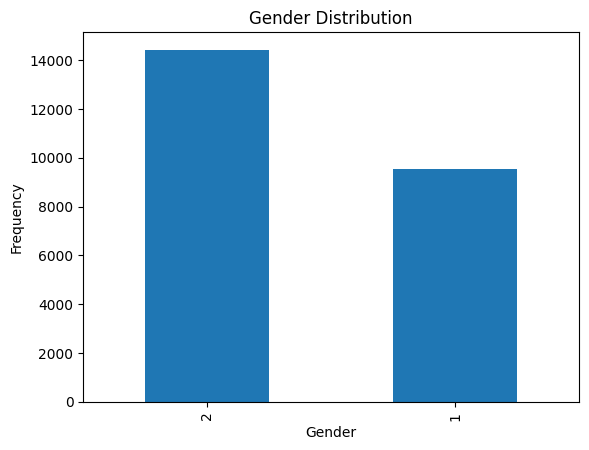

In [405]:
x_train['X2'].value_counts().plot(kind='bar')
plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.title('Gender Distribution')
plt.show

females are more than males in our data set

<function matplotlib.pyplot.show(close=None, block=None)>

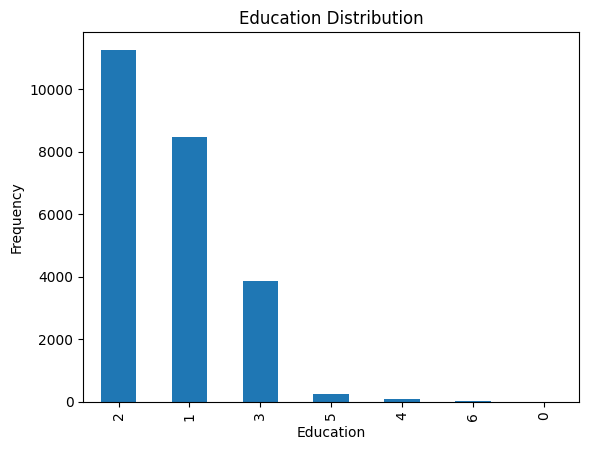

In [406]:
x_train['X3'].value_counts().plot(kind='bar')
plt.xlabel('Education')
plt.ylabel('Frequency')
plt.title('Education Distribution')
plt.show

high school and university is less than graduates

<function matplotlib.pyplot.show(close=None, block=None)>

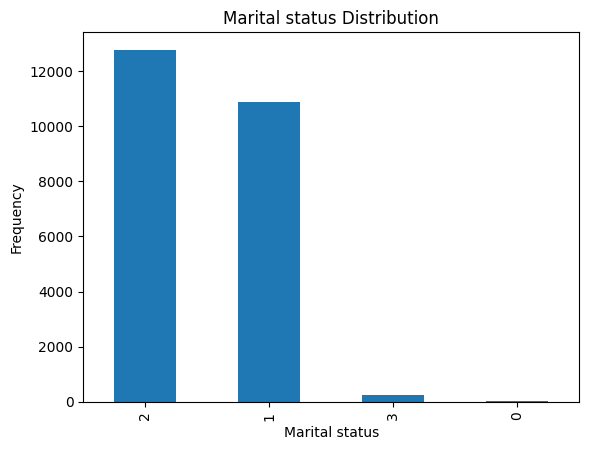

In [407]:
x_train['X4'].value_counts().plot(kind='bar')
plt.xlabel('Marital status')
plt.ylabel('Frequency')
plt.title('Marital status Distribution')
plt.show

married samples are more in our dataset than single ones

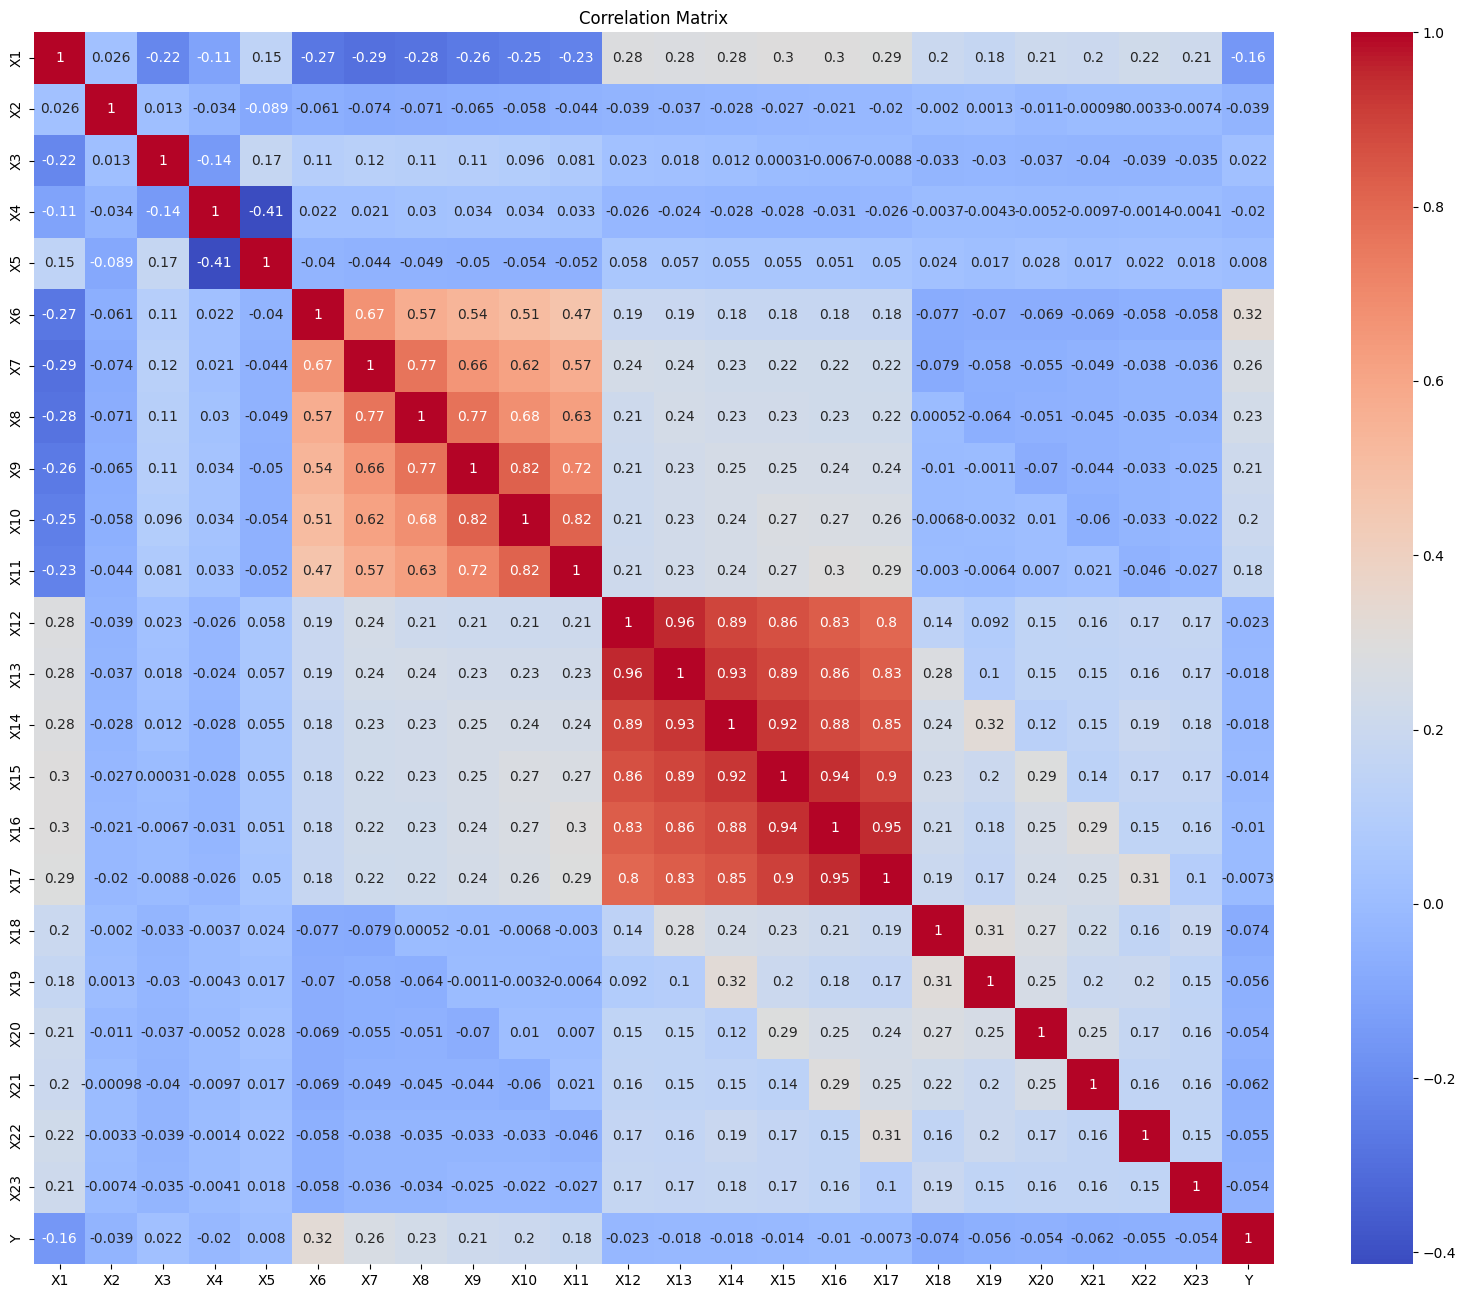

In [408]:
corr=train.corr(numeric_only=True)
plt.figure(figsize=(20, 16))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

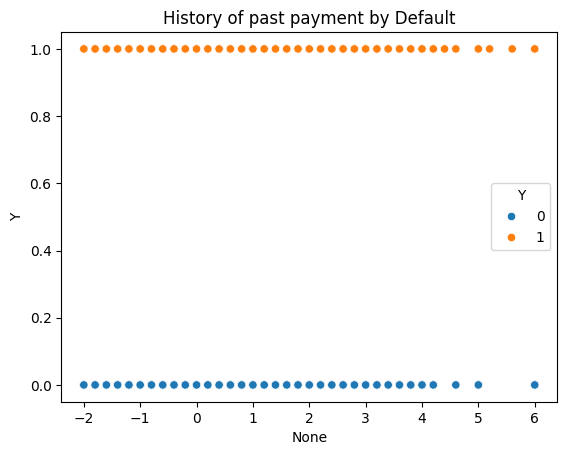

In [409]:
sns.scatterplot(
    x=x_train[['X6','X7','X8','X9','X10']].mean(axis=1),
    y=y_train,
    hue=y_train
)
plt.title("History of past payment by Default")
plt.show()

# preprocessing pipeline

In [410]:
x_train['X3'].replace([5,6,0],[4,4,4],inplace=True) # replace all the undocumented errored values with "other" category

/tmp/ipykernel_539/3549939384.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_train['X3'].replace([5,6,0],[4,4,4],inplace=True) # replace all the undocumented errored values with "other" category


In [411]:
x_train['X4'].replace([0],[3],inplace=True)  # replace all the undocumented errored values with "other" category

/tmp/ipykernel_539/2534759969.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_train['X4'].replace([0],[3],inplace=True)  # replace all the undocumented errored values with "other" category


In [412]:
x_train['X2'].replace([1,2],[0,1],inplace=True) # reEncode Gender with Binary encoding ( male-> 0 / female-> 1 )

/tmp/ipykernel_539/2304044286.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_train['X2'].replace([1,2],[0,1],inplace=True) # reEncode Gender with Binary encoding ( male-> 0 / female-> 1 )


In [413]:
marital_status_data = []
for marital_status in x_train['X4']:
  if marital_status==1:
    marital_status_data.append({
        'marital_status_msb':0,
        'marital_status_lsb':0
    })
  elif marital_status==2:
    marital_status_data.append({
        'marital_status_msb':0,
        'marital_status_lsb':1
    })
  else:
    marital_status_data.append({
        'marital_status_msb':1,
        'marital_status_lsb':0
    })
marital_status_df = pd.DataFrame(marital_status_data)
marital_status_df

,marital_status_msb,marital_status_lsb
0,0,0
1,1,0
2,0,1
3,0,1
4,0,1
...,...,...
23967,0,1
23968,0,1
23969,0,1
23970,0,1


In [414]:
x_train['X4']

,X4
0,1
1,3
2,2
3,2
4,2
...,...
23967,2
23968,2
23969,2
23970,2


In [415]:
x_train.drop(columns=['X4'],inplace=True)

In [416]:
x_train

,X1,X2,X3,X5,X6,X7,X8,X9,X10,X11,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,300000,0,2,35,-2,-2,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
1,50000,1,3,37,2,2,2,2,2,2,...,49325,48033,27019,26450,2300,1500,0,3400,0,1200
2,80000,0,1,23,-1,-1,-1,-1,0,0,...,444,888,888,444,444,444,888,444,0,1038
3,50000,1,2,26,-1,-1,-1,-1,-1,-1,...,390,390,0,780,2078,390,390,0,780,0
4,200000,0,2,30,-2,-2,-2,-2,-2,-2,...,24753,123439,132269,129224,20294,24891,125171,17816,26269,4349
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23967,10000,0,1,38,0,0,-1,-1,-1,-1,...,390,390,0,780,1000,390,390,0,780,0
23968,60000,1,2,24,-2,-2,-2,-2,-2,-2,...,0,0,479,27485,12270,0,0,479,27485,0
23969,70000,0,2,27,2,2,2,2,2,2,...,31130,31622,32102,32742,1800,1700,1300,1300,1300,1300
23970,140000,0,2,32,1,2,2,2,2,3,...,67734,73079,75255,75757,3200,0,6500,4000,2000,3000


In [417]:
pd.concat([x_train,marital_status_df],axis=1)

,X1,X2,X3,X5,X6,X7,X8,X9,X10,X11,...,X16,X17,X18,X19,X20,X21,X22,X23,marital_status_msb,marital_status_lsb
0,300000,0,2,35,-2,-2,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
1,50000,1,3,37,2,2,2,2,2,2,...,27019,26450,2300,1500,0,3400,0,1200,1,0
2,80000,0,1,23,-1,-1,-1,-1,0,0,...,888,444,444,444,888,444,0,1038,0,1
3,50000,1,2,26,-1,-1,-1,-1,-1,-1,...,0,780,2078,390,390,0,780,0,0,1
4,200000,0,2,30,-2,-2,-2,-2,-2,-2,...,132269,129224,20294,24891,125171,17816,26269,4349,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23967,10000,0,1,38,0,0,-1,-1,-1,-1,...,0,780,1000,390,390,0,780,0,0,1
23968,60000,1,2,24,-2,-2,-2,-2,-2,-2,...,479,27485,12270,0,0,479,27485,0,0,1
23969,70000,0,2,27,2,2,2,2,2,2,...,32102,32742,1800,1700,1300,1300,1300,1300,0,1
23970,140000,0,2,32,1,2,2,2,2,3,...,75255,75757,3200,0,6500,4000,2000,3000,0,1


### Feature Engineering

In [419]:
amount_of_bill_features=[f'X{i}' for i in range(12,18)]
x_train[f'average_utilization']=x_train[amount_of_bill_features].mean(axis=1)/x_train['X1'].replace(0,1)

In [420]:
previous_payment_features=[f'X{i}' for i in range(18,24)]
x_train['previous_pay_rel_to_bill']=x_train[previous_payment_features].mean(axis=1)/x_train[amount_of_bill_features].mean(axis=1).replace(0,1)

### Scaling

In [422]:
num_features=['X1','X5','X12','X13','X14','X15','X16','X17','X18','X19','X20','X21','X22','X23','previous_pay_rel_to_bill','average_utilization']

In [423]:
scaler=StandardScaler()

In [424]:
x_train[num_features]=scaler.fit_transform(x_train[num_features])

# Train

balance the training data

In [428]:
smote=SMOTE()

In [429]:
x_train,y_train=smote.fit_resample(x_train,y_train)

LDA

In [431]:
lda_model=LinearDiscriminantAnalysis()

In [432]:
lda_model.fit(x_train,y_train)

LinearDiscriminantAnalysis()

SVM

In [433]:
svm_model=SVC()

In [434]:
svm_model.fit(x_train,y_train)

SVC()

# preparing Test data (preprocessing)

In [436]:
x_test['X3'].replace([5,6,0],[4,4,4],inplace=True) # replace all the undocumented errored values with "other" category

/tmp/ipykernel_539/3384769146.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_test['X3'].replace([5,6,0],[4,4,4],inplace=True) # replace all the undocumented errored values with "other" category


In [437]:
x_test['X4'].replace([0],[3],inplace=True)  # replace all the undocumented errored values with "other" category

/tmp/ipykernel_539/2845019823.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_test['X4'].replace([0],[3],inplace=True)  # replace all the undocumented errored values with "other" category


In [438]:
x_test['X2'].replace([1,2],[0,1],inplace=True) # reEncode Gender with Binary encoding ( male-> 0 / female-> 1 )

/tmp/ipykernel_539/3540803734.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_test['X2'].replace([1,2],[0,1],inplace=True) # reEncode Gender with Binary encoding ( male-> 0 / female-> 1 )


In [439]:
marital_status_data = []
for marital_status in x_test['X4']:
  if marital_status==1:
    marital_status_data.append({
        'marital_status_msb':0,
        'marital_status_lsb':0
    })
  elif marital_status==2:
    marital_status_data.append({
        'marital_status_msb':0,
        'marital_status_lsb':1
    })
  else:
    marital_status_data.append({
        'marital_status_msb':1,
        'marital_status_lsb':0
    })
marital_status_df = pd.DataFrame(marital_status_data)
marital_status_df

,marital_status_msb,marital_status_lsb
0,0,0
1,0,0
2,0,1
3,0,1
4,0,1
...,...,...
5988,0,0
5989,0,0
5990,0,1
5991,0,1


In [440]:
x_test.drop(columns=['X4'],inplace=True)

In [441]:
pd.concat([x_test,marital_status_df],axis=1)

,X1,X2,X3,X5,X6,X7,X8,X9,X10,X11,...,X16,X17,X18,X19,X20,X21,X22,X23,marital_status_msb,marital_status_lsb
0,50000,1,3,43,0,0,0,0,0,0,...,8904,4740,2000,1500,3500,600,500,4000,0,0
1,240000,0,2,31,0,0,0,0,0,0,...,180809,184383,7648,7900,8000,6500,6900,7000,0,0
2,90000,1,1,25,0,0,0,0,0,0,...,11731,8138,1500,1500,1500,2000,1500,1000,0,1
3,50000,1,2,22,0,0,2,0,0,0,...,27173,26424,4809,0,1200,1500,943,1142,0,1
4,230000,0,1,32,0,0,0,0,0,0,...,42500,43531,10120,20000,10000,5000,5000,5000,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5988,70000,1,3,35,3,2,2,2,0,0,...,27850,28085,0,2708,0,1010,1013,2000,0,0
5989,60000,1,3,66,0,0,2,2,4,4,...,61670,65120,5000,5000,5000,5000,5000,1000,0,0
5990,30000,1,1,43,0,0,0,0,0,0,...,30452,0,1659,1589,1551,1124,0,0,0,1
5991,30000,1,3,26,0,0,0,0,0,0,...,13084,14206,1700,1500,1000,1500,1500,1500,0,1


In [442]:
amount_of_bill_features=[f'X{i}' for i in range(12,18)]
x_test[f'average_utilization']=x_test[amount_of_bill_features].mean(axis=1)/x_test['X1'].replace(0,1)

In [443]:
previous_payment_features=[f'X{i}' for i in range(18,24)]
x_test['previous_pay_rel_to_bill']=x_test[previous_payment_features].mean(axis=1)/x_test[amount_of_bill_features].mean(axis=1).replace(0,1)

In [444]:
x_test[num_features]=scaler.transform(x_test[num_features])

# predictions

In [445]:
lda_prediction=lda_model.predict(x_test)

In [446]:
svm_prediction=svm_model.predict(x_test)

#EVALUATION

lda

In [447]:
accuracy_score(y_test,lda_prediction)

0.6878024361755382

In [448]:
precision_score(y_test,lda_prediction)

0.3720056364490371

In [449]:
recall_score(y_test,lda_prediction)

0.5972850678733032

In [450]:
cm_lda=confusion_matrix(y_test,lda_prediction)

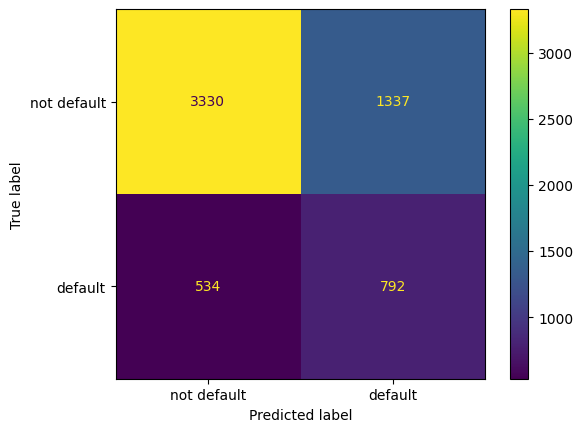

In [451]:
display=ConfusionMatrixDisplay(cm_lda,display_labels=['not default','default'])
display.plot()
plt.show()

In [452]:
print(classification_report(y_test,lda_prediction,target_names=['non default','default']))

              precision    recall  f1-score   support

 non default       0.86      0.71      0.78      4667
     default       0.37      0.60      0.46      1326

    accuracy                           0.69      5993
   macro avg       0.62      0.66      0.62      5993
weighted avg       0.75      0.69      0.71      5993



svm

In [453]:
accuracy_score(y_test,svm_prediction)

0.7668947104955782

In [454]:
cm_lda=confusion_matrix(y_test,svm_prediction)

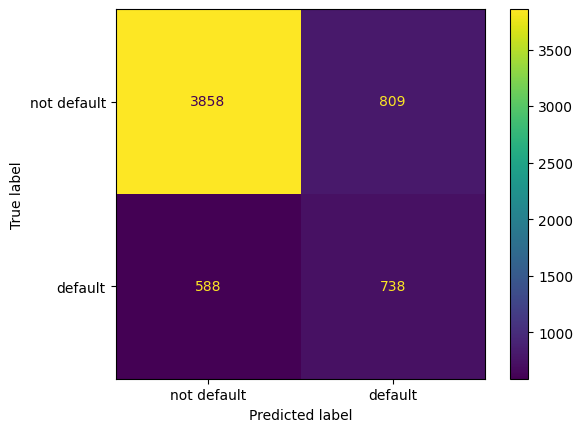

In [455]:
display=ConfusionMatrixDisplay(cm_lda,display_labels=['not default','default'])
display.plot()
plt.show()

In [456]:
print(classification_report(y_test,svm_prediction,target_names=['non default','default']))

              precision    recall  f1-score   support

 non default       0.87      0.83      0.85      4667
     default       0.48      0.56      0.51      1326

    accuracy                           0.77      5993
   macro avg       0.67      0.69      0.68      5993
weighted avg       0.78      0.77      0.77      5993



# hyperparameter tuning

In [457]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1],
}

grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(x_train, y_train)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


GridSearchCV(cv=3, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 0.01, 0.1]},
             scoring='f1', verbose=2)

In [ ]:
print(grid_search.best_params_)   # which combination won
print(grid_search.best_score_)    # its cross-validated F1 score

best_svm = grid_search.best_estimator_
predicted_svm_tuned = best_svm.predict(x_test)
print(classification_report(y_test, predicted_svm_tuned, target_names=['non default','default']))